In [2]:
import matplotlib.pyplot as plt
import pandas as pd

In [50]:
df = pd.read_csv("./build/op", names=["idx", "real", "imag"])

In [51]:
df

,idx,real,imag
0,0,0.008087,0.000000
1,1,0.011455,-0.004207
2,2,0.002088,0.000503
3,3,0.010334,-0.000414
4,4,0.009315,0.000134
...,...,...,...
66145,66145,0.007335,0.001038
66146,66146,0.004872,-0.002509
66147,66147,0.009927,0.000575
66148,66148,0.007254,-0.001756


<Axes: xlabel='idx'>

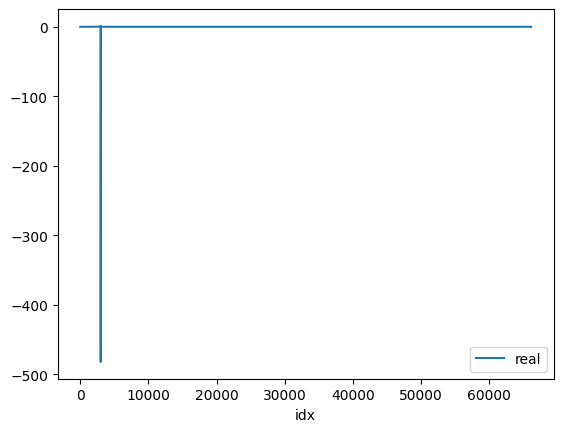

In [52]:
df.plot(x="idx", y="real")

In [53]:
df["real"].idxmax()

2999

In [54]:
df["freq"] = (44100 * df["idx"]) / len(df)

In [55]:
df

,idx,real,imag,freq
0,0,0.008087,0.000000,0.000000
1,1,0.011455,-0.004207,0.666667
2,2,0.002088,0.000503,1.333333
3,3,0.010334,-0.000414,2.000000
4,4,0.009315,0.000134,2.666667
...,...,...,...,...
66145,66145,0.007335,0.001038,44096.666667
66146,66146,0.004872,-0.002509,44097.333333
66147,66147,0.009927,0.000575,44098.000000
66148,66148,0.007254,-0.001756,44098.666667


In [56]:
df[(df["freq"] < 2010) & (df["freq"] > 1995)]

,idx,real,imag,freq
2993,2993,0.183296,21.9020,1995.333333
2994,2994,0.211991,25.5618,1996.000000
2995,2995,0.255035,30.6829,1996.666667
2996,2996,0.314458,38.3643,1997.333333
2997,2997,0.416513,51.1709,1998.000000
2998,2998,0.622827,76.7998,1998.666667
2999,2999,1.235890,153.8260,1999.333333
3000,3000,-482.109000,-60560.2000,2000.000000
3001,3001,-1.212180,-153.0960,2000.666667
3002,3002,-0.606535,-76.6579,2001.333333


In [57]:
df = pd.read_csv("./build/op_song", names=["idx", "real", "imag"])

In [58]:
df

,idx,real,imag
0,0,5.40254,0.000000
1,1,-2.66847,-1.806380
2,2,2.65274,4.803290
3,3,0.74613,-5.721630
4,4,-1.02738,8.113640
...,...,...,...
110245,110245,1.04430,0.454436
110246,110246,1.87699,-1.614880
110247,110247,3.24874,0.326837
110248,110248,1.65564,-0.246550


<Axes: xlabel='idx'>

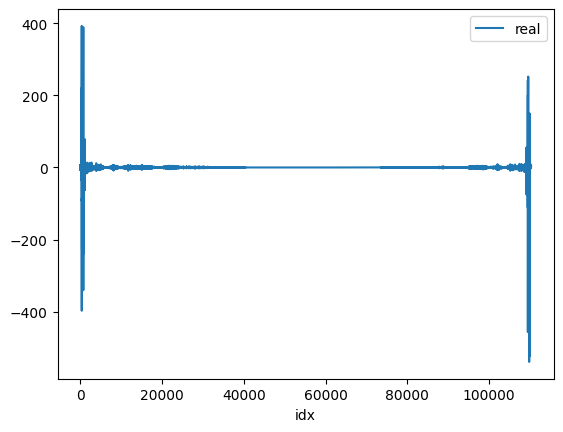

In [59]:
df.plot(x="idx", y="real")

In [60]:
df["real"].idxmax()

389

In [63]:
df["freq"] = (44100 * df["idx"]) / len(df)
df["mag"] = (df["real"] ** 2 + df["imag"] ** 2) ** 0.5

In [64]:
df

,idx,real,imag,freq,mag
0,0,5.40254,0.000000,0.0,5.402540
1,1,-2.66847,-1.806380,0.4,3.222381
2,2,2.65274,4.803290,0.8,5.487133
3,3,0.74613,-5.721630,1.2,5.770075
4,4,-1.02738,8.113640,1.6,8.178427
...,...,...,...,...,...
110245,110245,1.04430,0.454436,44098.0,1.138892
110246,110246,1.87699,-1.614880,44098.4,2.476071
110247,110247,3.24874,0.326837,44098.8,3.265139
110248,110248,1.65564,-0.246550,44099.2,1.673897


<Axes: xlabel='freq'>

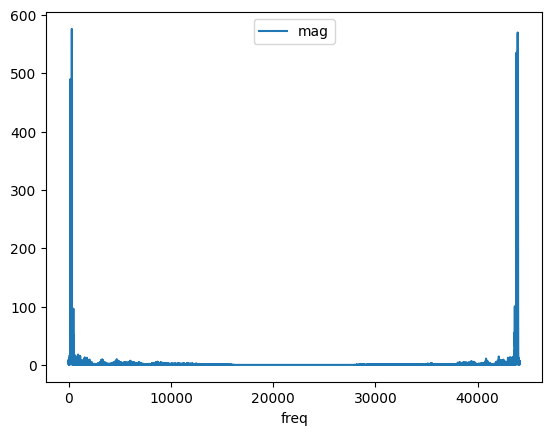

In [69]:
df.plot(x="freq", y="mag")

<Axes: xlabel='freq'>

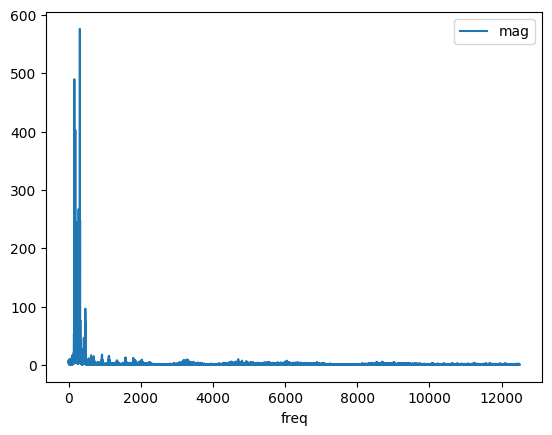

In [ ]:
df[df["freq"] < 12_500].plot(x="freq", y="mag")

### viz sine, raw, and after no moidification fft

In [23]:
with open("./build/op") as f:
    op = f.read()

In [5]:
inp, out = op.split("_")
inp = [int(i) for i in inp.split("\n") if i.strip() != '']
out = [int(i) for i in out.split("\n") if i.strip() != '']

# plt.plot(inp[350:550])
plt.plot(inp[0:250])

ValueError: invalid literal for int() with base 10: '14367.1'

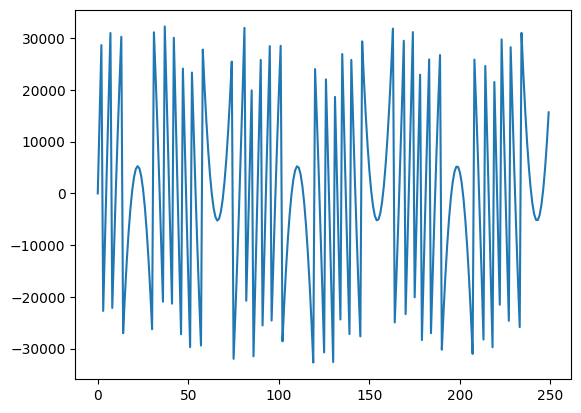

In [30]:
# plt.plot(out[350:550])
plt.plot(out[0:250])
# looks like high frequency stuff messes it up somehow

### viz sine, raw, and after no moidification fft -> now direct float print, no cast to int.

In [1]:
with open("./build/op") as f:
    op = f.read()

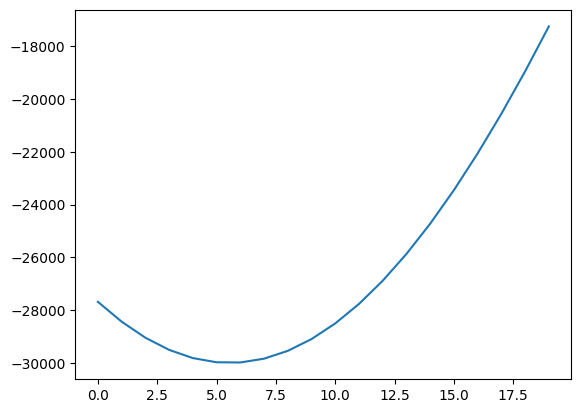

In [11]:
inp, out = op.split("_")
inp = [float(i) for i in inp.split("\n") if i.strip() != '']
out = [float(i) for i in out.split("\n") if i.strip() != '']

# plt.plot(inp[350:550])
plt.plot(inp[678:698])

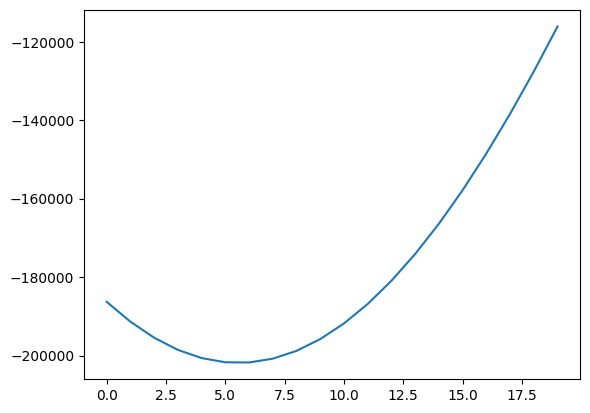

In [10]:
# plt.plot(out[350:550])
plt.plot(out[678:698])

In [45]:
df = pd.read_csv("./build/op", names=["frame", "idx", "real", "imag"])

In [46]:
len(df)

216090

In [52]:
df["freq"] = (44100 * df["idx"]) / 4410
df["mag"] = (df["real"] ** 2 + df["imag"] ** 2) ** 0.5
df["mag"] = (df["mag"] - df["mag"].min()) / (df["mag"].max() - df["mag"].min())

In [53]:
len(df.groupby(by=["frame"]))

49

In [54]:
df[df["frame"] == 0]

,frame,idx,real,imag,freq,mag
0,0,0,0.276742,0.000000,0.0,0.002643
1,0,1,0.278968,0.032591,10.0,0.002682
2,0,2,0.257289,0.058867,20.0,0.002521
3,0,3,0.263448,0.041148,30.0,0.002546
4,0,4,0.285418,0.090846,40.0,0.002861
...,...,...,...,...,...,...
4405,0,4405,0.000000,0.000000,44050.0,0.000000
4406,0,4406,0.000000,0.000000,44060.0,0.000000
4407,0,4407,0.000000,0.000000,44070.0,0.000000
4408,0,4408,0.000000,0.000000,44080.0,0.000000


In [56]:
for frame, frame_df in df.groupby(by=["frame"]):
    plt_df = frame_df[(df["idx"] < (4410 // 2)) & (df["freq"] < 12_000)]
    plt.plot(plt_df["freq"], plt_df["mag"], color='black')
    plt.ylim(0, 1)
    plt.savefig(f"./frames/{frame[0]}_frame.jpg", dpi=100)
    plt.close()
    

/tmp/ipykernel_40981/3230912178.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  plt_df = frame_df[(df["idx"] < (4410 // 2)) & (df["freq"] < 12_000)]
/tmp/ipykernel_40981/3230912178.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  plt_df = frame_df[(df["idx"] < (4410 // 2)) & (df["freq"] < 12_000)]
/tmp/ipykernel_40981/3230912178.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  plt_df = frame_df[(df["idx"] < (4410 // 2)) & (df["freq"] < 12_000)]
/tmp/ipykernel_40981/3230912178.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  plt_df = frame_df[(df["idx"] < (4410 // 2)) & (df["freq"] < 12_000)]
/tmp/ipykernel_40981/3230912178.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  plt_df = frame_df[(df["idx"] < (4410 // 2)) & (df["freq"] < 12_000)]
/tmp/ipykernel_40981/3230912178.py:2: UserWarning: Boolean Series key will 